# 03 — Sensitivity, Study A: delineation scale

The comparison in `02b` left one question open. Terrain accounts for 46 to 48% of
the difference between this project's assessment and the USGS one, and that share
is confounded with basin size: USGS delineated 562 catchments at a median of
0.082 km², this project 237 at 0.379 km². Small basins sit on a single hillslope
and take extreme values of T; larger ones average across ridges and gullies.

This notebook runs the delineation at three minimum basin areas and measures how
much of the terrain difference is explained by scale alone.

| Run | minimum basin area | why |
|---|---|---|
| fine | 0.05 km² | reaches the USGS median of 0.082 km² |
| baseline | 0.10 km² | the M1 calibration floor, unchanged from notebook 01 |
| coarse | 0.50 km² | tests the other direction, giving a trend rather than two points |

The maximum stays at 8 km² in all three. Changing both ends at once would make
any result unattributable to either.

**The fine run is an extrapolation by this project's own rule.** Design decision 7
flags basins outside 0.1 to 8 km² as outside the range M1 was fitted on. It is run
anyway, and labelled, because USGS operates there and the whole point is to
compare like with like. If it turns out that scale explains most of the terrain
difference, then the calibration floor as currently cited is doing more work in
this project's design than it does in operational practice, and that is worth
knowing.

**Results are reported in area terms, not per basin.** The three runs produce
different numbers of differently shaped basins, so there is no basin to follow
across them. What can be compared is what fraction of the burn area each run
rates as hazardous.

Nothing is refetched. The DEM, the dNBR product and the soil polygons all come
from Drive, written by notebook 01.

---
## Cell 1 — Load the saved products and rebuild the routing surfaces

Everything raster comes off disk. The one piece of real work is conditioning and
flow routing, which takes about a minute and is done once here because all three
runs share it: changing the minimum basin area changes which outlets are chosen,
not how water flows.

Slope comes from the raw DEM and routing from the conditioned one, as in notebook
01. Severity is expanded from its native 20 m to the 10 m terrain grid by 2x2
block replication, which is exact because the grids were snapped to nest.

In [ ]:
# Cell 1 --- setup, saved rasters, routing surfaces

%cd /content
!pip install -q pysheds

import os, sys, subprocess, json, importlib
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio import features
from google.colab import drive

drive.mount('/content/drive')

REPO_URL = 'https://github.com/jerrod-lessel/scar-threshold.git'
REPO_DIR = '/content/postfire-debris-flow'
if os.path.isdir(REPO_DIR):
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--quiet'], check=False)
else:
    subprocess.run(['git', 'clone', '--quiet', REPO_URL, REPO_DIR], check=True)
if f'{REPO_DIR}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_DIR}/src')

from debrisflow import terrain, severity, soils, basins as basins_mod, m1
for mod in (terrain, severity, soils, basins_mod, m1):
    importlib.reload(mod)

FIRE_DIR = Path('/content/drive/MyDrive/postfire-debris-flow/bridge_2024')
SENS_DIR = FIRE_DIR / 'sensitivity'
SENS_DIR.mkdir(parents=True, exist_ok=True)
TARGET_CRS = 'EPSG:32611'
DEM_RES = 10

# --- Rasters ------------------------------------------------------------------
DEM_PATH = FIRE_DIR / 'terrain' / 'bridge_2024_dem_10m.tif'
with rasterio.open(DEM_PATH) as src:
    dem = src.read(1).astype('float32')
    dem_transform = src.transform
    dem_profile = src.profile
print(f'DEM   : {dem.shape}, {np.nanmin(dem):.0f} to {np.nanmax(dem):.0f} m')

DNBR_PATH = FIRE_DIR / 'severity' / 'bridge_2024_dnbr_20m.tif'
with rasterio.open(DNBR_PATH) as src:
    dnbr20 = src.read(1).astype('float32')
    sev_transform = src.transform
print(f'dNBR  : {dnbr20.shape} at 20 m')

perimeter = gpd.read_file(
    FIRE_DIR / 'perimeter' / 'bridge_2024_perimeter.geojson').to_crs(TARGET_CRS)
perim_geom = perimeter.geometry.iloc[0]
burn_dem = features.rasterize([(perim_geom, 1)], out_shape=dem.shape,
                              transform=dem_transform, fill=0,
                              dtype='uint8').astype(bool)
print(f'burn  : {burn_dem.sum() * 100 / 1e6:.1f} km2')

# --- Severity onto the 10 m grid ---------------------------------------------
row_off = (dem_transform.f - sev_transform.f) / DEM_RES
col_off = (sev_transform.c - dem_transform.c) / DEM_RES
assert float(row_off).is_integer() and float(col_off).is_integer(), \
    'grids do not nest; block expansion is invalid'
row_off, col_off = int(row_off), int(col_off)

big = np.repeat(np.repeat(dnbr20, 2, axis=0), 2, axis=1)
dnbr10 = np.full(dem.shape, np.nan, dtype='float32')
r1 = min(row_off + big.shape[0], dem.shape[0])
c1 = min(col_off + big.shape[1], dem.shape[1])
dnbr10[row_off:r1, col_off:c1] = big[:r1 - row_off, :c1 - col_off]
mh10 = severity.moderate_high_mask(dnbr10)
print(f'severity expanded, valid over {np.isfinite(dnbr10).mean():.1%} of the DEM')

# --- Routing and slope --------------------------------------------------------
from pysheds.grid import Grid
grid = Grid.from_raster(str(DEM_PATH))
dem_raster = grid.read_raster(str(DEM_PATH))
print('\nconditioning...')
conditioned = terrain.condition_dem(grid, dem_raster)
fdir, acc = terrain.flow_grids(grid, conditioned)
fdir_arr, acc_arr = np.asarray(fdir), np.asarray(acc)

slope = terrain.slope_degrees(dem, cellsize_m=DEM_RES)
steep = terrain.steep_mask(slope, threshold=23.0)
print(f'slope : mean {np.nanmean(slope):.1f} deg, '
      f'{steep[burn_dem].mean():.1%} of the burn is >= 23 deg')

OUTLET_BUFFER_M = 2000
region = features.rasterize([(perim_geom.buffer(OUTLET_BUFFER_M), 1)],
                            out_shape=dem.shape, transform=dem_transform,
                            fill=0, dtype='uint8').astype(bool)
print(f'outlet region: {region.sum() * 100 / 1e6:.0f} km2')

/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.1 MB/s eta 0:00:00
Mounted at /content/drive
DEM   : (4090, 3254), 196 to 3068 m
dNBR  : (1545, 1127) at 20 m
burn  : 226.6 km2
severity expanded, valid over 52.3% of the DEM

conditioning...
slope : mean 22.5 deg, 83.0% of the burn is >= 23 deg
outlet region: 412 km2


---
## Cell 2 — Soil lookup

The STATSGO polygons are already on disk from notebook 01. Only the tabular query
runs again, and it covers ten map units, so it is small.

This uses the project's baseline soil rule: surface horizon, null KF values
dropped and renormalised. The soil rule is an axis in Study B, not here. Holding
it fixed is what makes any difference between the three runs attributable to
delineation scale.

In [2]:
# Cell 2 --- KF per map unit, baseline rule

mu = gpd.read_file(FIRE_DIR / 'soils' / 'statsgo_mapunits.geojson').to_crs(TARGET_CRS)
mu['mukey'] = mu.mukey.astype(str)
mukeys = sorted(mu.mukey.unique())

rows = soils.sda_query(soils.kf_by_mapunit_sql(mukeys, dataset='statsgo'))
kf_lookup = soils.kf_by_mapunit(rows, surface_only=True)
print(f'map units {len(mukeys)}, horizon rows {len(rows):,}, '
      f'with KF {len(kf_lookup)}')
for k in mukeys:
    v = kf_lookup.get(k)
    print(f'  {k}: ' + (f'KF {v[0]:.4f}' if v else 'no KF'))

map units 10, horizon rows 465, with KF 10
  660456: KF 0.2967
  660470: KF 0.2674
  660471: KF 0.2715
  660474: KF 0.2432
  660484: KF 0.2121
  660494: KF 0.2415
  660499: KF 0.2628
  660500: KF 0.2440
  660501: KF 0.3390
  660505: KF 0.2588


---
## Cell 3 — Run the three delineations

For each minimum basin area: delineate, compute T, F and S per basin, score with
M1, and record both per-basin results and an area-weighted summary.

Two things are held constant so the comparison is clean. The maximum basin area
stays at 8 km², and the outlet region stays at the perimeter plus 2 km. Only the
minimum moves.

`in_calibration_range` is recorded per basin, so the fine run's extrapolation
is visible in the output rather than implied by the run label.

In [3]:
# Cell 3 --- delineate and score at three scales

from scipy import ndimage

MIN_AREAS = {'fine': 0.05, 'baseline': 0.10, 'coarse': 0.50}
MAX_AREA = 8.0
REFERENCE_STORM = 24
INTENSITY = m1.RainfallConvention.INTENSITY_MM_HR

per_basin, summaries, label_rasters = {}, [], {}

for run_name, min_area in MIN_AREAS.items():
    print(f'\n=== {run_name}: minimum {min_area} km2 ===')
    min_cells = int(terrain.cells_for_area(min_area, cellsize_m=DEM_RES))
    max_cells = int(terrain.cells_for_area(MAX_AREA, cellsize_m=DEM_RES))

    labels, records = basins_mod.delineate(fdir_arr, acc_arr,
                                           min_cells=min_cells,
                                           max_cells=max_cells,
                                           region_mask=region)
    attrs = basins_mod.basin_attributes(labels, records, burn_dem,
                                        cellsize_m=DEM_RES)
    touching = [a for a in attrs if a['overlap_fraction'] > 0]
    print(f'  basins touching the burn: {len(touching):,}')

    slices = ndimage.find_objects(labels)
    out = []
    for a in touching:
        i = a['id']
        sl = slices[i - 1]
        mask = labels[sl] == i
        T = float(terrain.basin_T(steep[sl], mh10[sl], mask))
        F_raw = float(severity.basin_F(dnbr10[sl], mask))
        F = max(F_raw, 0.0)
        out.append({**a, 'T': T, 'F_raw': F_raw, 'F': F})

    # Polygonise, then dissolve by id.
    keep = {a['id'] for a in touching}
    from shapely.geometry import shape as shp_shape
    geoms, ids = [], []
    for geom, val in features.shapes(labels, mask=labels > 0,
                                     transform=dem_transform):
        v = int(val)
        if v in keep:
            geoms.append(shp_shape(geom)); ids.append(v)
    poly = gpd.GeoDataFrame({'id': ids}, geometry=geoms, crs=TARGET_CRS)
    poly = poly.dissolve(by='id', as_index=False)

    df = pd.DataFrame(out)
    gdf = poly.merge(df, on='id', how='left')

    # --- Soil, area weighted from the STATSGO polygons ------------------------
    inter = gpd.overlay(gdf[['id', 'geometry']], mu[['mukey', 'geometry']],
                        how='intersection', keep_geom_type=True)
    inter['area_m2'] = inter.geometry.area
    s_rows = []
    for bid, grp in inter.groupby('id'):
        kfs = [kf_lookup.get(k, (np.nan,))[0] if kf_lookup.get(k) else np.nan
               for k in grp.mukey]
        val, cov = soils.weighted_mean(kfs, grp.area_m2.tolist())
        s_rows.append({'id': bid, 'S': float(val), 'S_coverage': float(cov)})
    gdf = gdf.merge(pd.DataFrame(s_rows), on='id', how='left')
    gdf = gdf.dropna(subset=['T', 'F', 'S'])

    # --- Score ----------------------------------------------------------------
    thr, p24 = [], []
    for _, r in gdf.iterrows():
        bv = m1.BasinVariables(T=float(r['T']), F=float(r['F']), S=float(r['S']))
        p24.append(float(m1.likelihood(bv, REFERENCE_STORM,
                                       convention=INTENSITY, duration_min=15)))
        try:
            thr.append(float(m1.accumulation(bv, target_p=0.5, duration_min=15,
                                             out_convention=INTENSITY)))
        except Exception:
            thr.append(np.inf)
    gdf['p_24'] = p24
    gdf['threshold_mm_hr'] = thr
    gdf['run'] = run_name
    gdf['min_area_km2'] = min_area

    # --- Area weighted summary over BURNED area only --------------------------
    wt = gdf.burned_cells.to_numpy() * 100.0        # m2 of burn in each basin
    def warea_median(v, weights):
        okm = np.isfinite(v) & (weights > 0)
        v, weights = v[okm], weights[okm]
        o = np.argsort(v); v, weights = v[o], weights[o]
        c = np.cumsum(weights) / weights.sum()
        return float(v[np.searchsorted(c, 0.5)])

    thr_arr = gdf.threshold_mm_hr.to_numpy()
    p_arr = gdf.p_24.to_numpy()
    burn_total = burn_dem.sum() * 100.0

    summaries.append({
        'run': run_name,
        'min_area_km2': min_area,
        'basins': len(gdf),
        'median_basin_km2': float(gdf.area_km2.median()),
        'below_calibration': int((~gdf.in_calibration_range).sum()),
        'burn_area_in_basins_pct': float(wt.sum() / burn_total * 100),
        'median_T': float(gdf['T'].median()),
        'area_wt_median_T': warea_median(gdf['T'].to_numpy(), wt),
        'area_wt_median_thr': warea_median(thr_arr, wt),
        'burn_area_High_pct': float(wt[p_arr >= 0.6].sum() / wt.sum() * 100),
    })
    per_basin[run_name] = gdf
    label_rasters[run_name] = labels
    gdf.to_file(SENS_DIR / f'basins_{run_name}.geojson', driver='GeoJSON')
    print(f'  saved -> basins_{run_name}.geojson')

summary = pd.DataFrame(summaries)
print('\n=== Study A summary ===')
print(summary.round(3).to_string(index=False))
summary.to_csv(SENS_DIR / 'study_a_delineation_summary.csv', index=False)


=== fine: minimum 0.05 km2 ===


  basins touching the burn: 352
  saved -> basins_fine.geojson

=== baseline: minimum 0.1 km2 ===
  basins touching the burn: 237
  saved -> basins_baseline.geojson

=== coarse: minimum 0.5 km2 ===
  basins touching the burn: 106
  saved -> basins_coarse.geojson

=== Study A summary ===
     run  min_area_km2  basins  median_basin_km2  below_calibration  burn_area_in_basins_pct  median_T  area_wt_median_T  area_wt_median_thr  burn_area_High_pct
    fine          0.05     352             0.194                115                   90.867     0.817             0.684              18.014              64.137
baseline          0.10     237             0.379                  0                   87.625     0.779             0.670              18.109              63.358
  coarse          0.50     106             1.653                  0                   76.194     0.482             0.636              19.327              60.585


---
## Cell 4 — Compare against the USGS reference point

The question this notebook exists to answer: how much of the terrain difference
with USGS is explained by delineation scale alone?

The USGS reference figures, from notebook `02b`, are 37.2% of the shared area
rated High at 24 mm/hr and an area-weighted median threshold of 25.8 mm/hr, at a
median catchment size of 0.082 km².

If the fine run moves toward those figures, scale explains part of the gap and
the size of that part can be stated. If it moves away, or does not move, then the
terrain difference is in slope or severity processing rather than in how the
ground was divided up, and design decision 7 stands as written.

--- Study A against the USGS reference ---
     run  min_area_km2  basins  median_basin_km2  below_calibration  area_wt_median_T  area_wt_median_thr  burn_area_High_pct
    fine          0.05     352             0.194                115             0.684              18.014              64.137
baseline          0.10     237             0.379                  0             0.670              18.109              63.358
  coarse          0.50     106             1.653                  0             0.636              19.327              60.585

USGS: median basin 0.082 km2, 37.2% of area High, 25.8 mm/hr median threshold

baseline threshold 18.11 vs USGS 25.80, gap -7.69 mm/hr
moving to the fine delineation shifts it +0.10 mm/hr
that is 1% of the gap, in the WRONG direction


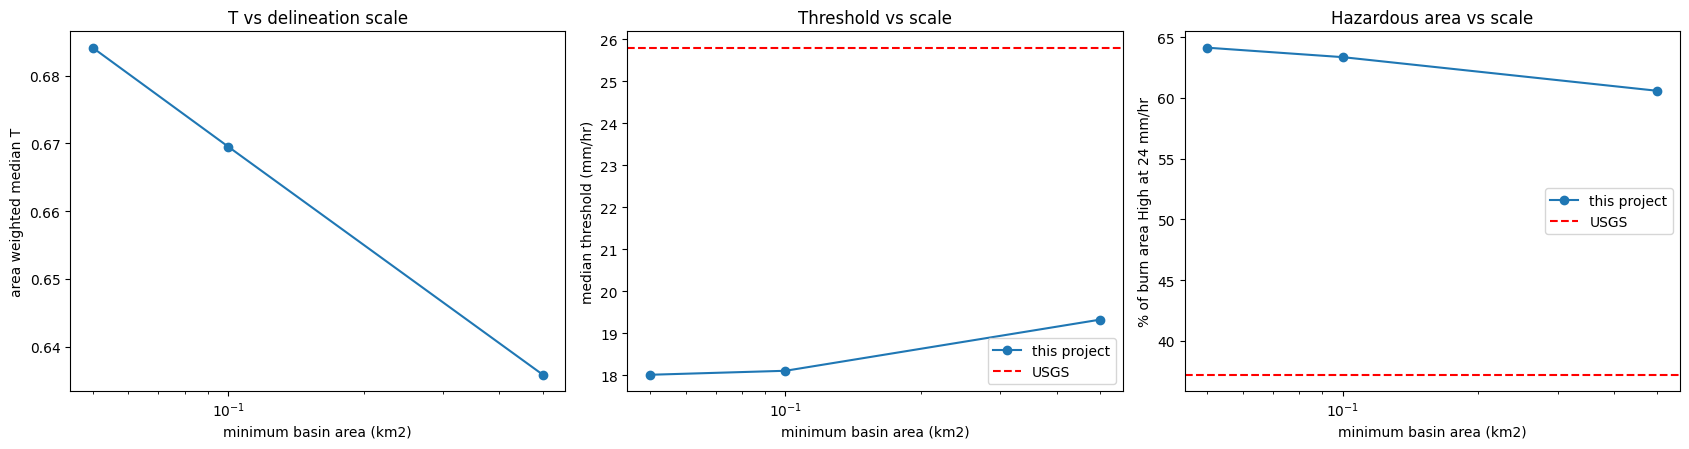

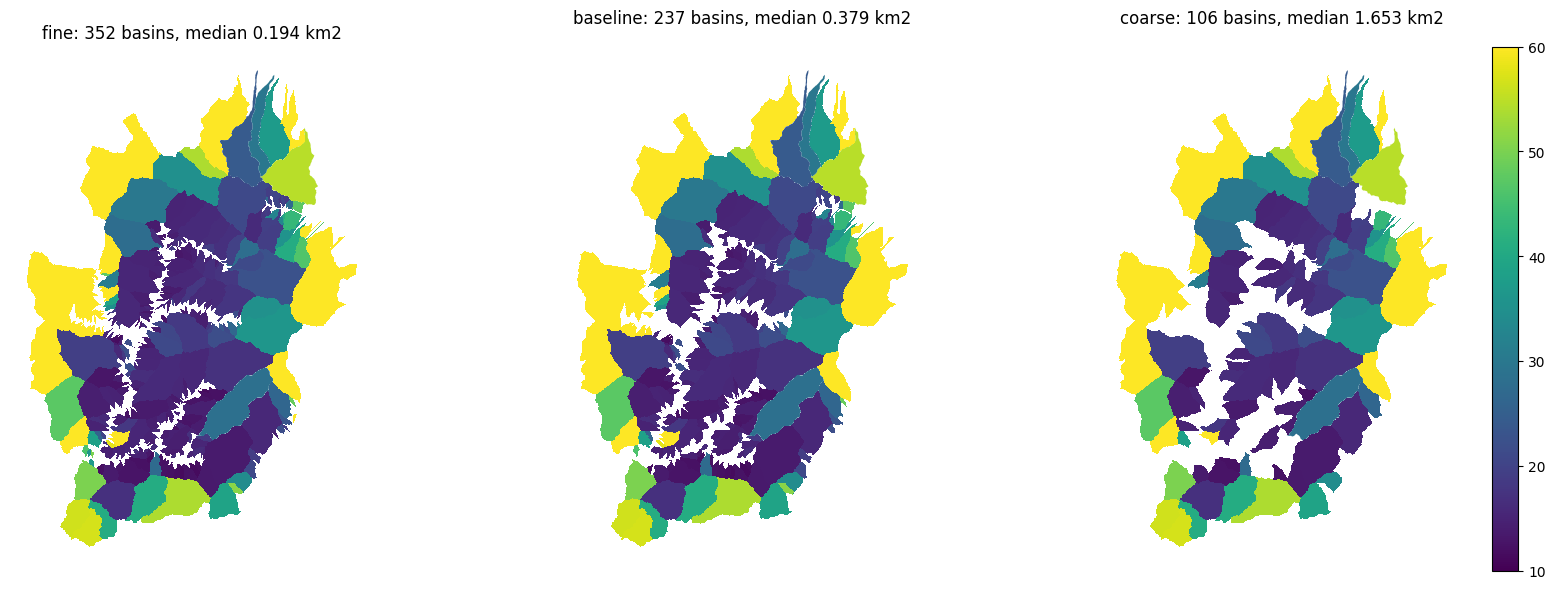

In [4]:
# Cell 4 --- read the result against the USGS reference

USGS_REF = {'median_basin_km2': 0.082,
            'burn_area_High_pct': 37.2,
            'area_wt_median_thr': 25.8}

print('--- Study A against the USGS reference ---')
tab = summary[['run', 'min_area_km2', 'basins', 'median_basin_km2',
               'below_calibration', 'area_wt_median_T',
               'area_wt_median_thr', 'burn_area_High_pct']].copy()
print(tab.round(3).to_string(index=False))
print(f'\nUSGS: median basin {USGS_REF["median_basin_km2"]:.3f} km2, '
      f'{USGS_REF["burn_area_High_pct"]:.1f}% of area High, '
      f'{USGS_REF["area_wt_median_thr"]:.1f} mm/hr median threshold')

base = summary[summary.run == 'baseline'].iloc[0]
fine = summary[summary.run == 'fine'].iloc[0]
gap_total = base.area_wt_median_thr - USGS_REF['area_wt_median_thr']
gap_closed = base.area_wt_median_thr - fine.area_wt_median_thr
print(f'\nbaseline threshold {base.area_wt_median_thr:.2f} vs USGS '
      f'{USGS_REF["area_wt_median_thr"]:.2f}, gap {gap_total:+.2f} mm/hr')
print(f'moving to the fine delineation shifts it {gap_closed:+.2f} mm/hr')
if abs(gap_total) > 1e-9:
    print(f'that is {gap_closed / gap_total * 100:.0f}% of the gap, '
          'in the direction of USGS' if gap_closed / gap_total > 0 else
          f'that is {abs(gap_closed / gap_total) * 100:.0f}% of the gap, '
          'in the WRONG direction')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
x = summary.min_area_km2
ax[0].plot(x, summary.area_wt_median_T, 'o-')
ax[0].set_xscale('log'); ax[0].set_xlabel('minimum basin area (km2)')
ax[0].set_ylabel('area weighted median T'); ax[0].set_title('T vs delineation scale')

ax[1].plot(x, summary.area_wt_median_thr, 'o-', label='this project')
ax[1].axhline(USGS_REF['area_wt_median_thr'], color='r', ls='--', label='USGS')
ax[1].set_xscale('log'); ax[1].set_xlabel('minimum basin area (km2)')
ax[1].set_ylabel('median threshold (mm/hr)'); ax[1].legend()
ax[1].set_title('Threshold vs scale')

ax[2].plot(x, summary.burn_area_High_pct, 'o-', label='this project')
ax[2].axhline(USGS_REF['burn_area_High_pct'], color='r', ls='--', label='USGS')
ax[2].set_xscale('log'); ax[2].set_xlabel('minimum basin area (km2)')
ax[2].set_ylabel('% of burn area High at 24 mm/hr'); ax[2].legend()
ax[2].set_title('Hazardous area vs scale')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(17, 6))
for a, run_name in zip(ax, MIN_AREAS):
    g = per_basin[run_name]
    g.plot(column='threshold_mm_hr', ax=a, cmap='viridis', vmin=10, vmax=60,
           legend=(run_name == 'coarse'))
    a.set_title(f'{run_name}: {len(g)} basins, '
                f'median {g.area_km2.median():.3f} km2')
    a.axis('off')
plt.tight_layout(); plt.show()

###Cells 3 and 4 re-done

In [5]:
# Cell 3 --- delineate and score at three scales

from scipy import ndimage

MIN_AREAS = {'ultrafine': 0.02, 'fine': 0.05, 'baseline': 0.10, 'coarse': 0.50}
MAX_AREA = 8.0
REFERENCE_STORM = 24
INTENSITY = m1.RainfallConvention.INTENSITY_MM_HR

per_basin, summaries, label_rasters = {}, [], {}

for run_name, min_area in MIN_AREAS.items():
    print(f'\n=== {run_name}: minimum {min_area} km2 ===')
    min_cells = int(terrain.cells_for_area(min_area, cellsize_m=DEM_RES))
    max_cells = int(terrain.cells_for_area(MAX_AREA, cellsize_m=DEM_RES))

    labels, records = basins_mod.delineate(fdir_arr, acc_arr,
                                           min_cells=min_cells,
                                           max_cells=max_cells,
                                           region_mask=region)
    attrs = basins_mod.basin_attributes(labels, records, burn_dem,
                                        cellsize_m=DEM_RES)
    touching = [a for a in attrs if a['overlap_fraction'] > 0]
    print(f'  basins touching the burn: {len(touching):,}')

    slices = ndimage.find_objects(labels)
    out = []
    for a in touching:
        i = a['id']
        sl = slices[i - 1]
        mask = labels[sl] == i
        T = float(terrain.basin_T(steep[sl], mh10[sl], mask))
        F_raw = float(severity.basin_F(dnbr10[sl], mask))
        F = max(F_raw, 0.0)
        out.append({**a, 'T': T, 'F_raw': F_raw, 'F': F})

    # Polygonise, then dissolve by id.
    keep = {a['id'] for a in touching}
    from shapely.geometry import shape as shp_shape
    geoms, ids = [], []
    for geom, val in features.shapes(labels, mask=labels > 0,
                                     transform=dem_transform):
        v = int(val)
        if v in keep:
            geoms.append(shp_shape(geom)); ids.append(v)
    poly = gpd.GeoDataFrame({'id': ids}, geometry=geoms, crs=TARGET_CRS)
    poly = poly.dissolve(by='id', as_index=False)

    df = pd.DataFrame(out)
    gdf = poly.merge(df, on='id', how='left')

    # --- Soil, area weighted from the STATSGO polygons ------------------------
    inter = gpd.overlay(gdf[['id', 'geometry']], mu[['mukey', 'geometry']],
                        how='intersection', keep_geom_type=True)
    inter['area_m2'] = inter.geometry.area
    s_rows = []
    for bid, grp in inter.groupby('id'):
        kfs = [kf_lookup.get(k, (np.nan,))[0] if kf_lookup.get(k) else np.nan
               for k in grp.mukey]
        val, cov = soils.weighted_mean(kfs, grp.area_m2.tolist())
        s_rows.append({'id': bid, 'S': float(val), 'S_coverage': float(cov)})
    gdf = gdf.merge(pd.DataFrame(s_rows), on='id', how='left')
    gdf = gdf.dropna(subset=['T', 'F', 'S'])

    # --- Score ----------------------------------------------------------------
    thr, p24 = [], []
    for _, r in gdf.iterrows():
        bv = m1.BasinVariables(T=float(r['T']), F=float(r['F']), S=float(r['S']))
        p24.append(float(m1.likelihood(bv, REFERENCE_STORM,
                                       convention=INTENSITY, duration_min=15)))
        try:
            thr.append(float(m1.accumulation(bv, target_p=0.5, duration_min=15,
                                             out_convention=INTENSITY)))
        except Exception:
            thr.append(np.inf)
    gdf['p_24'] = p24
    gdf['threshold_mm_hr'] = thr
    gdf['run'] = run_name
    gdf['min_area_km2'] = min_area

    # --- Area weighted summary over BURNED area only --------------------------
    wt = gdf.burned_cells.to_numpy() * 100.0        # m2 of burn in each basin
    def warea_median(v, weights):
        okm = np.isfinite(v) & (weights > 0)
        v, weights = v[okm], weights[okm]
        o = np.argsort(v); v, weights = v[o], weights[o]
        c = np.cumsum(weights) / weights.sum()
        return float(v[np.searchsorted(c, 0.5)])

    thr_arr = gdf.threshold_mm_hr.to_numpy()
    p_arr = gdf.p_24.to_numpy()
    burn_total = burn_dem.sum() * 100.0

    summaries.append({
        'run': run_name,
        'min_area_km2': min_area,
        'basins': len(gdf),
        'median_basin_km2': float(gdf.area_km2.median()),
        'below_calibration': int((~gdf.in_calibration_range).sum()),
        'burn_area_in_basins_pct': float(wt.sum() / burn_total * 100),
        'median_T': float(gdf['T'].median()),
        'area_wt_median_T': warea_median(gdf['T'].to_numpy(), wt),
        'area_wt_median_thr': warea_median(thr_arr, wt),
        'burn_area_High_pct': float(wt[p_arr >= 0.6].sum() / wt.sum() * 100),
    })
    per_basin[run_name] = gdf
    label_rasters[run_name] = labels
    gdf.to_file(SENS_DIR / f'basins_{run_name}.geojson', driver='GeoJSON')
    print(f'  saved -> basins_{run_name}.geojson')

summary = pd.DataFrame(summaries)
print('\n=== Study A summary ===')
print(summary.round(3).to_string(index=False))
summary.to_csv(SENS_DIR / 'study_a_delineation_summary.csv', index=False)


=== ultrafine: minimum 0.02 km2 ===
  basins touching the burn: 566
  saved -> basins_ultrafine.geojson

=== fine: minimum 0.05 km2 ===
  basins touching the burn: 352
  saved -> basins_fine.geojson

=== baseline: minimum 0.1 km2 ===
  basins touching the burn: 237
  saved -> basins_baseline.geojson

=== coarse: minimum 0.5 km2 ===
  basins touching the burn: 106
  saved -> basins_coarse.geojson

=== Study A summary ===
      run  min_area_km2  basins  median_basin_km2  below_calibration  burn_area_in_basins_pct  median_T  area_wt_median_T  area_wt_median_thr  burn_area_High_pct
ultrafine          0.02     566             0.070                329                   93.708     0.822             0.684              17.762              64.595
     fine          0.05     352             0.194                115                   90.867     0.817             0.684              18.014              64.137
 baseline          0.10     237             0.379                  0                   87

--- Study A against the USGS reference ---
      run  min_area_km2  basins  median_basin_km2  below_calibration  area_wt_median_T  area_wt_median_thr  burn_area_High_pct
ultrafine          0.02     566             0.070                329             0.684              17.762              64.595
     fine          0.05     352             0.194                115             0.684              18.014              64.137
 baseline          0.10     237             0.379                  0             0.670              18.109              63.358
   coarse          0.50     106             1.653                  0             0.636              19.327              60.585

USGS: median basin 0.082 km2, 37.2% of area High, 25.8 mm/hr median threshold

baseline threshold 18.11 vs USGS 25.80, gap -7.69 mm/hr
moving to the fine delineation shifts it +0.10 mm/hr
that is 1% of the gap, in the WRONG direction


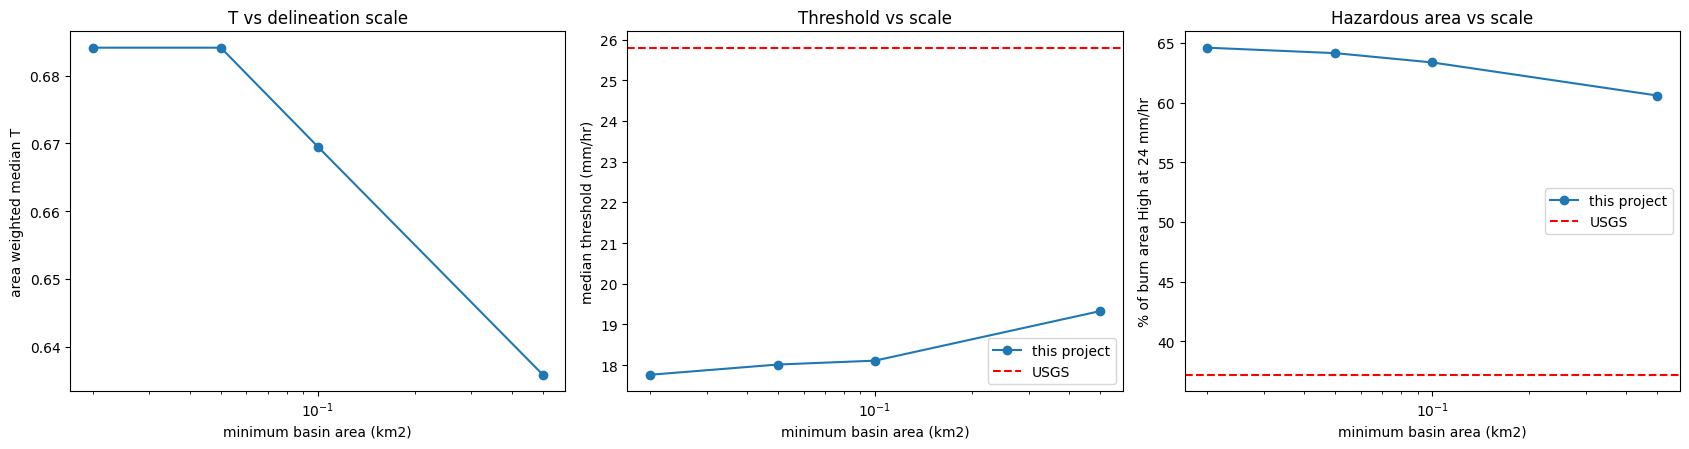

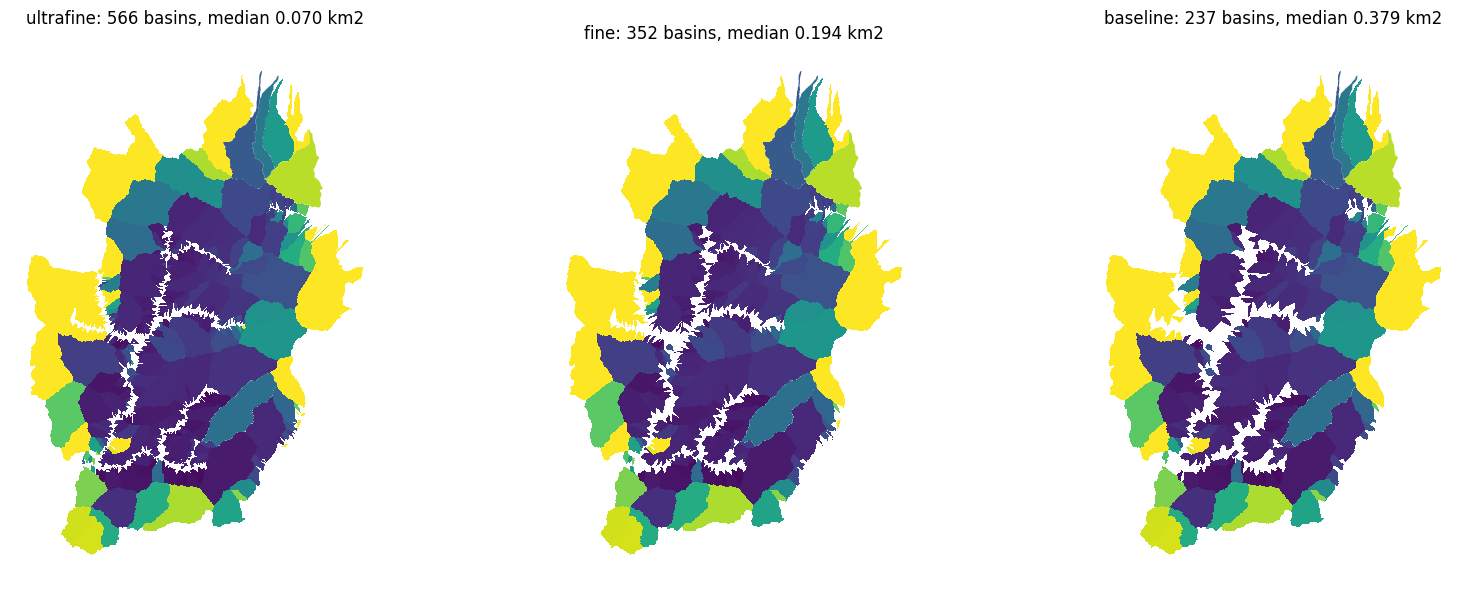

In [6]:
# Cell 4 --- read the result against the USGS reference

USGS_REF = {'median_basin_km2': 0.082,
            'burn_area_High_pct': 37.2,
            'area_wt_median_thr': 25.8}

print('--- Study A against the USGS reference ---')
tab = summary[['run', 'min_area_km2', 'basins', 'median_basin_km2',
               'below_calibration', 'area_wt_median_T',
               'area_wt_median_thr', 'burn_area_High_pct']].copy()
print(tab.round(3).to_string(index=False))
print(f'\nUSGS: median basin {USGS_REF["median_basin_km2"]:.3f} km2, '
      f'{USGS_REF["burn_area_High_pct"]:.1f}% of area High, '
      f'{USGS_REF["area_wt_median_thr"]:.1f} mm/hr median threshold')

base = summary[summary.run == 'baseline'].iloc[0]
fine = summary[summary.run == 'fine'].iloc[0]
gap_total = base.area_wt_median_thr - USGS_REF['area_wt_median_thr']
gap_closed = base.area_wt_median_thr - fine.area_wt_median_thr
print(f'\nbaseline threshold {base.area_wt_median_thr:.2f} vs USGS '
      f'{USGS_REF["area_wt_median_thr"]:.2f}, gap {gap_total:+.2f} mm/hr')
print(f'moving to the fine delineation shifts it {gap_closed:+.2f} mm/hr')
if abs(gap_total) > 1e-9:
    print(f'that is {gap_closed / gap_total * 100:.0f}% of the gap, '
          'in the direction of USGS' if gap_closed / gap_total > 0 else
          f'that is {abs(gap_closed / gap_total) * 100:.0f}% of the gap, '
          'in the WRONG direction')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
x = summary.min_area_km2
ax[0].plot(x, summary.area_wt_median_T, 'o-')
ax[0].set_xscale('log'); ax[0].set_xlabel('minimum basin area (km2)')
ax[0].set_ylabel('area weighted median T'); ax[0].set_title('T vs delineation scale')

ax[1].plot(x, summary.area_wt_median_thr, 'o-', label='this project')
ax[1].axhline(USGS_REF['area_wt_median_thr'], color='r', ls='--', label='USGS')
ax[1].set_xscale('log'); ax[1].set_xlabel('minimum basin area (km2)')
ax[1].set_ylabel('median threshold (mm/hr)'); ax[1].legend()
ax[1].set_title('Threshold vs scale')

ax[2].plot(x, summary.burn_area_High_pct, 'o-', label='this project')
ax[2].axhline(USGS_REF['burn_area_High_pct'], color='r', ls='--', label='USGS')
ax[2].set_xscale('log'); ax[2].set_xlabel('minimum basin area (km2)')
ax[2].set_ylabel('% of burn area High at 24 mm/hr'); ax[2].legend()
ax[2].set_title('Hazardous area vs scale')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(17, 6))
for a, run_name in zip(ax, MIN_AREAS):
    g = per_basin[run_name]
    g.plot(column='threshold_mm_hr', ax=a, cmap='viridis', vmin=10, vmax=60,
           legend=(run_name == 'coarse'))
    a.set_title(f'{run_name}: {len(g)} basins, '
                f'median {g.area_km2.median():.3f} km2')
    a.axis('off')
plt.tight_layout(); plt.show()

---
# Part B — Substituting the actual BAER soil burn severity

Study A ruled out delineation scale as the cause of the terrain difference with
USGS. The USGS documentation identifies what the cause almost certainly is.

Their terrain variable is the proportion of upslope area in BARC class 3 or 4
with gradients at or above 23 degrees. BARC classes are not a fixed dNBR
threshold. BAER teams classify a dNBR raster into four classes using break values
chosen per fire, then adjust those breaks and hand-correct individual areas based
on field checking, for example remapping pixels where soil burn severity did not
match the canopy condition above it.

For the Bridge Fire, BAER published the result: of the 54,659 acres analysed,
about 42% is unburned, very low or low soil burn severity, 51% moderate and 7%
high. **Moderate or high is 58% of the burn area.** This project's dNBR >= 270
classification gives **76.5%**.

That is an 18.5 percentage point difference in the input to the strongest
predictor in the model, and it runs exactly the direction predicted for chaparral:
shrubs burn to nothing above ground, giving high dNBR, while the soil beneath is
only moderately affected.

## Why substitute the raster rather than tune a threshold

The obvious response is to raise the dNBR threshold until the moderate-high
fraction reaches 58%. That would be weaker than it looks. T does not depend on
the total burned fraction; it depends on where severity coincides with slopes at
or above 23 degrees. Two severity maps with identical totals can produce very
different T.

The BAER product is the actual input, with the actual spatial pattern and the
field corrections included. Substituting it tests the real thing rather than a
proxy for it.

**The swap is surgical.** Only the moderate/high mask changes. F stays as this
project's dNBR, because USGS defines F as mean catchment dNBR as well, and the
two already agree at r = 0.965. So any change in the result is attributable to
the severity classification alone.

## Cell 5 — Locate and fetch the BAER SBS raster

The Forest Service publishes a national SBS mosaic covering all BAER incidents
from 2017 onward, as a four-class thematic raster at 20 m or 30 m depending on
the source imagery. It is served as an ArcGIS ImageServer, which exports a
GeoTIFF for a bounding box over ordinary HTTPS.

This cell tries several published endpoints, exports the burn area, and reports
the class histogram. Nothing is computed from it yet. The point is to confirm the
Bridge Fire is actually in the mosaic and that the class proportions resemble the
published 42 / 51 / 7 split before anything is built on top of it.

Export request: 917 x 1334 px at 20 m, EPSG:32611
[ok  ] geoplatform imagery: "Fire_Aviation/USFS_EDW_BAER_SoilBurnSeverityClassification", pixel type U4, bands 1
[got ] geoplatform imagery: (1334, 917), 1.05 MB

--- Class histogram over the export window ---
    0 nodata / outside          630,919 px ( 51.6%)
    1 unburned to very low       71,650 px (  5.9%)
    2 low                       192,181 px ( 15.7%)
    3 moderate                  290,826 px ( 23.8%)
    4 high                       37,702 px (  3.1%)

--- Inside the fire perimeter ---
pixels in perimeter : 565,669
with an SBS class   : 548,793 (97.0% coverage)
  unburned to very low       58,617 px ( 10.7%)
  low                       172,159 px ( 31.4%)
  moderate                  280,371 px ( 51.1%)
  high                       37,646 px (  6.9%)

moderate or high    : 57.9%
BAER published      : 58%  (51% moderate + 7% high)
this project, dNBR  : 76.5%

>>> Matches the published split. This is the Bridge Fire SBS.

Sav

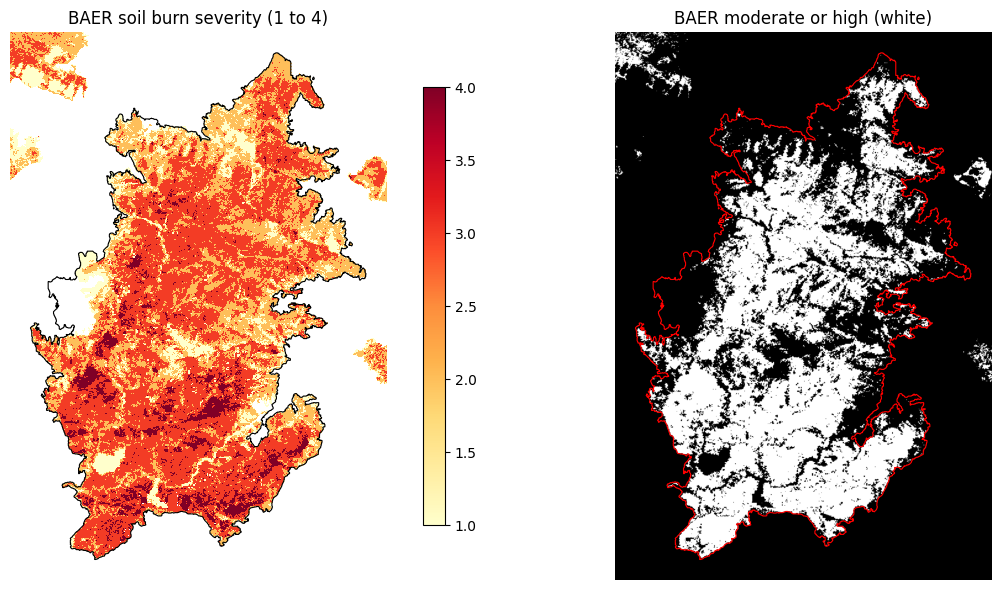

In [7]:
# Cell 5 --- fetch the BAER soil burn severity raster for the burn area

import io
import json
import numpy as np
import requests
import rasterio
from rasterio.io import MemoryFile
from rasterio.warp import transform_bounds

SBS_DIR = FIRE_DIR / 'baer'
SBS_DIR.mkdir(parents=True, exist_ok=True)
SBS_PATH = SBS_DIR / 'bridge_2024_sbs.tif'

# Published endpoints for the national BAER SBS mosaic, most likely first.
ENDPOINTS = [
    ('geoplatform imagery',
     'https://imagery.geoplatform.gov/iipp/rest/services/Fire_Aviation/'
     'USFS_EDW_BAER_SoilBurnSeverityClassification/ImageServer'),
    ('USFS EDW fsgisx03',
     'https://apps.fs.usda.gov/fsgisx03/rest/services/wo_nfs_gtac/'
     'EDW_BAERSoilBurnSeverityClassification_01/ImageServer'),
    ('USFS EDW fsgisx01',
     'https://apps.fs.usda.gov/fsgisx01/rest/services/wo_nfs_gtac/'
     'EDW_BAERSoilBurnSeverityClassification_01/ImageServer'),
]

# Export extent: the burn perimeter with a small margin, in UTM 11N.
bx = perimeter.total_bounds
margin = 1000
export_bbox = (bx[0] - margin, bx[1] - margin, bx[2] + margin, bx[3] + margin)
width = int((export_bbox[2] - export_bbox[0]) / 20)
height = int((export_bbox[3] - export_bbox[1]) / 20)
print(f'Export request: {width} x {height} px at 20 m, {TARGET_CRS}')

sbs, sbs_transform, used = None, None, None
for label, base in ENDPOINTS:
    # First check the service is reachable and describe itself.
    try:
        info = requests.get(base, params={'f': 'json'}, timeout=60).json()
        if 'error' in info:
            print(f'[skip] {label}: {info["error"].get("message")}')
            continue
        print(f'[ok  ] {label}: "{info.get("name")}", '
              f'pixel type {info.get("pixelType")}, '
              f'bands {info.get("bandCount")}')
    except Exception as e:
        print(f'[skip] {label}: {type(e).__name__}')
        continue

    try:
        r = requests.get(f'{base}/exportImage', params={
            'bbox': ','.join(str(v) for v in export_bbox),
            'bboxSR': 32611, 'imageSR': 32611,
            'size': f'{width},{height}',
            'format': 'tiff', 'pixelType': 'U8',
            'noData': 0, 'interpolation': 'RSP_NearestNeighbor',
            'f': 'image',
        }, timeout=300)
        r.raise_for_status()
        if r.headers.get('content-type', '').startswith('application/json'):
            print(f'[fail] {label}: {r.text[:200]}')
            continue
        with MemoryFile(r.content) as mem, mem.open() as src:
            sbs = src.read(1)
            sbs_transform = src.transform
        used = label
        print(f'[got ] {label}: {sbs.shape}, {len(r.content)/1e6:.2f} MB')
        break
    except Exception as e:
        print(f'[fail] {label}: {type(e).__name__}: {e}')

if sbs is None:
    raise RuntimeError(
        'No BAER SBS raster returned. The service URLs may have moved. '
        'The Burn Severity Portal at burnseverity.cr.usgs.gov also offers '
        'per-fire downloads as a manual fallback.')

# --- What is in it? -----------------------------------------------------------
vals, counts = np.unique(sbs, return_counts=True)
print(f'\n--- Class histogram over the export window ---')
CLASS_NAMES = {0: 'nodata / outside', 1: 'unburned to very low', 2: 'low',
               3: 'moderate', 4: 'high'}
for v, c in zip(vals, counts):
    print(f'  {v:>3} {CLASS_NAMES.get(int(v), "?"):22s} {c:>10,} px '
          f'({c / sbs.size:6.1%})')

# --- Inside the perimeter only, which is what BAER quoted ---------------------
from rasterio import features
burn_sbs = features.rasterize([(perim_geom, 1)], out_shape=sbs.shape,
                              transform=sbs_transform, fill=0,
                              dtype='uint8').astype(bool)
inside = sbs[burn_sbs]
classified = inside[inside > 0]

print(f'\n--- Inside the fire perimeter ---')
print(f'pixels in perimeter : {burn_sbs.sum():,}')
print(f'with an SBS class   : {classified.size:,} '
      f'({classified.size / max(burn_sbs.sum(), 1):.1%} coverage)')
if classified.size:
    for v in (1, 2, 3, 4):
        n = int((classified == v).sum())
        print(f'  {CLASS_NAMES[v]:22s} {n:>10,} px ({n / classified.size:6.1%})')
    mh = ((classified == 3) | (classified == 4)).sum() / classified.size
    print(f'\nmoderate or high    : {mh:.1%}')
    print(f'BAER published      : 58%  (51% moderate + 7% high)')
    print(f'this project, dNBR  : 76.5%')
    if abs(mh - 0.58) < 0.05:
        print('\n>>> Matches the published split. This is the Bridge Fire SBS.')
    else:
        print('\n>>> Does NOT match the published 58%. Check that the mosaic '
              'covers this fire and that class values are as expected before '
              'using it.')

# --- Save ---------------------------------------------------------------------
prof = {'driver': 'GTiff', 'height': sbs.shape[0], 'width': sbs.shape[1],
        'count': 1, 'dtype': 'uint8', 'nodata': 0, 'crs': TARGET_CRS,
        'transform': sbs_transform, 'compress': 'deflate', 'tiled': True}
with rasterio.open(SBS_PATH, 'w', **prof) as dst:
    dst.write(sbs.astype('uint8'), 1)
    dst.set_band_description(1, 'BAER_soil_burn_severity_1to4')
    dst.update_tags(source=used, fire='Bridge 2024',
                    classes='1 unburned-verylow, 2 low, 3 moderate, 4 high')
print(f'\nSaved -> {SBS_PATH}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
im = ax[0].imshow(np.where(sbs > 0, sbs, np.nan), cmap='YlOrRd', vmin=1, vmax=4,
                  interpolation='nearest')
ax[0].contour(burn_sbs.astype(float), levels=[0.5], colors='black', linewidths=0.8)
ax[0].set_title('BAER soil burn severity (1 to 4)'); ax[0].axis('off')
plt.colorbar(im, ax=ax[0], shrink=0.8)

sbs_mh = np.isin(sbs, [3, 4])
ax[1].imshow(sbs_mh, cmap='gray')
ax[1].contour(burn_sbs.astype(float), levels=[0.5], colors='red', linewidths=0.8)
ax[1].set_title('BAER moderate or high (white)'); ax[1].axis('off')
plt.tight_layout(); plt.show()


---
## Cell 6 — Recompute T with the BAER severity mask

The substitution is surgical. Only the moderate/high mask changes:

- **Before:** `severity.moderate_high_mask(dnbr)`, which thresholds at dNBR >= 270
- **After:** BAER soil burn severity classes 3 and 4, field validated

Everything else is held fixed. The same DEM, the same Horn slope, the same
conditioned routing, the same basins, the same soil values. F stays as this
project's dNBR, because USGS defines F as mean catchment dNBR as well and the two
already agree at r = 0.965. So any change in T is attributable to the severity
classification and nothing else.

**Two delineations are run.** The baseline 237 basins are what this project
reports. The ultrafine 566 basins were delineated at a 0.02 km² minimum, which is
the drainage threshold USGS documents for their own assessments, and produced
566 basins against their 562. Running both means the finding does not depend on
which basin set is chosen.

**Grid alignment.** The BAER raster came back at 20 m in UTM 11N, the same
projection as everything else, but its origin was set by the export request
rather than snapped to the terrain grid. It is therefore resampled to the 10 m
terrain grid by nearest neighbour, which replicates a class value rather than
interpolating between classes. Interpolating a categorical raster would invent
severity classes that do not exist.

**What to look for.** The question is not whether T falls. It must, since the
burned fraction drops from 76.5% to 57.9%. The question is how far, and whether
it lands near the USGS values. T counts severity only where slope is at or above
23 degrees, so if the unburned threads in the BAER map follow drainage bottoms
they sit on flatter ground and T will barely move. If they follow slopes, T will
drop sharply. The percentages alone cannot tell you which.

--- Severity masks on the 10 m terrain grid ---
BAER coverage inside the burn : 96.9%
BAER moderate-high, burn area : 56.2%
dNBR moderate-high, burn area : 76.5%

--- On slopes >= 23 degrees inside the burn ---
BAER moderate-high : 56.6%
dNBR moderate-high : 76.5%

--- On slopes below 23 degrees inside the burn ---
BAER moderate-high : 54.2%
dNBR moderate-high : 76.3%

saved -> basins_baseline_baer.geojson  (SBS coverage median 1.000)

saved -> basins_ultrafine_baer.geojson  (SBS coverage median 1.000)

=== Severity substitution ===
delineation     severity  basins  area_wt_T  area_wt_thr  area_High_pct
   baseline  dNBR >= 270     237      0.670       18.109         63.358
   baseline BAER SBS 3-4     237      0.471       19.948         52.114
  ultrafine  dNBR >= 270     566      0.684       17.762         64.595
  ultrafine BAER SBS 3-4     566      0.475       19.948         53.502

USGS published: median T 0.531, 37.2% of area High, 25.8 mm/hr

baseline:
  T   0.670 -> 0.471
  thr

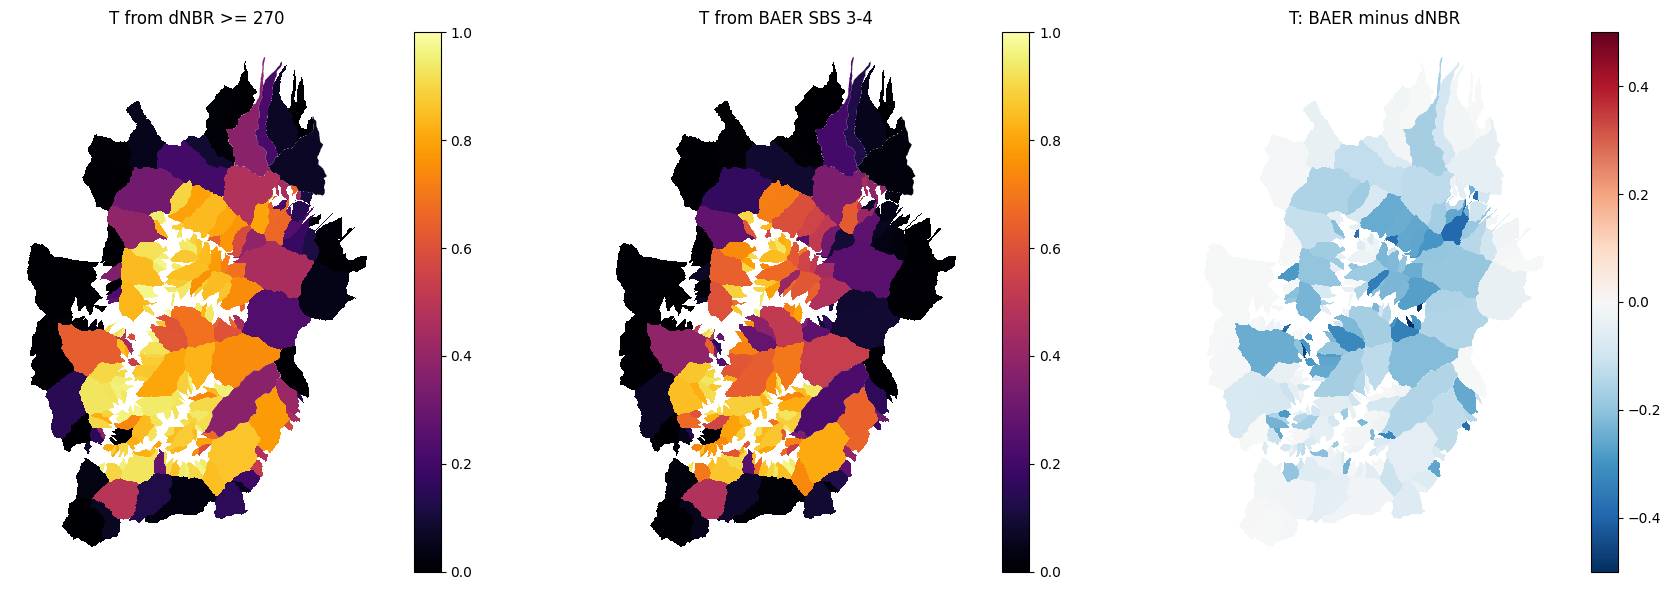

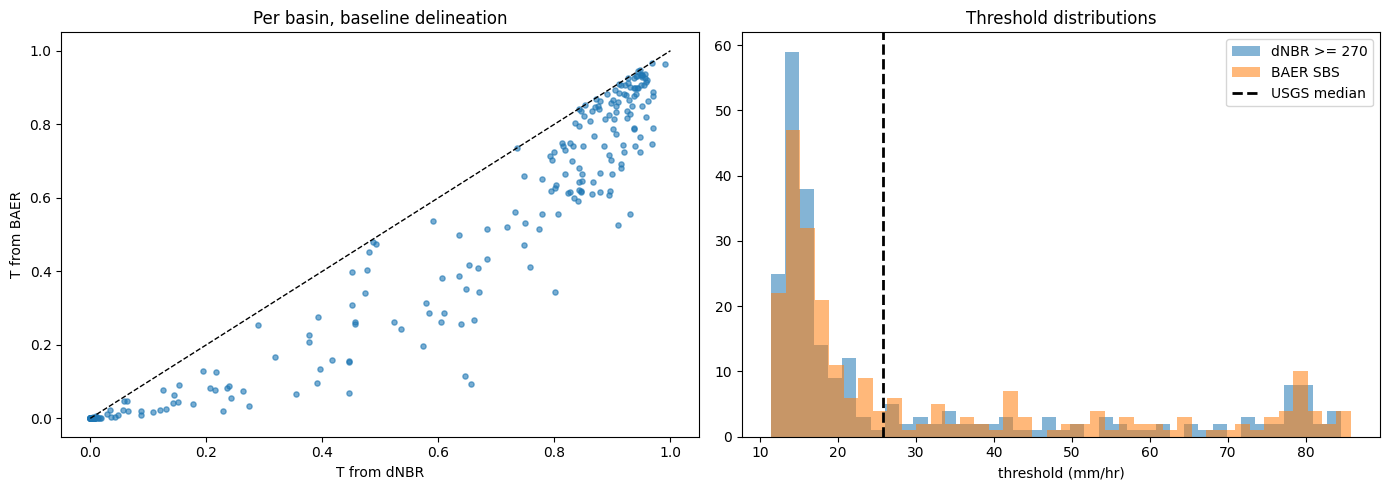

In [8]:
# Cell 6 --- swap in the BAER severity mask and recompute T

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from rasterio.warp import reproject
from scipy import ndimage

# --- Put the BAER raster on the 10 m terrain grid -----------------------------
# Nearest neighbour: these are classes, not measurements. Interpolating between
# class 2 and class 4 would produce a class 3 that nobody mapped.
sbs10 = np.zeros(dem.shape, dtype='uint8')
reproject(source=sbs, destination=sbs10,
          src_transform=sbs_transform, src_crs=TARGET_CRS,
          dst_transform=dem_transform, dst_crs=TARGET_CRS,
          resampling=Resampling.nearest, src_nodata=0, dst_nodata=0)

mh_baer = np.isin(sbs10, [3, 4])
sbs_valid = sbs10 > 0

print('--- Severity masks on the 10 m terrain grid ---')
print(f'BAER coverage inside the burn : {sbs_valid[burn_dem].mean():.1%}')
print(f'BAER moderate-high, burn area : {mh_baer[burn_dem].mean():.1%}')
print(f'dNBR moderate-high, burn area : {mh10[burn_dem].mean():.1%}')

# The question T actually asks: severity ON STEEP GROUND.
steep_burn = steep & burn_dem
print(f'\n--- On slopes >= 23 degrees inside the burn ---')
print(f'BAER moderate-high : {mh_baer[steep_burn].mean():.1%}')
print(f'dNBR moderate-high : {mh10[steep_burn].mean():.1%}')
flat_burn = (~steep) & burn_dem
print(f'\n--- On slopes below 23 degrees inside the burn ---')
print(f'BAER moderate-high : {mh_baer[flat_burn].mean():.1%}')
print(f'dNBR moderate-high : {mh10[flat_burn].mean():.1%}')

# --- Recompute T and rescore, for both delineations ---------------------------
REFERENCE_STORM = 24
INTENSITY = m1.RainfallConvention.INTENSITY_MM_HR
RUNS = ['baseline', 'ultrafine']

def warea_median(v, weights):
    okm = np.isfinite(v) & (weights > 0)
    v, weights = np.asarray(v)[okm], np.asarray(weights)[okm]
    o = np.argsort(v); v, weights = v[o], weights[o]
    c = np.cumsum(weights) / weights.sum()
    return float(v[np.searchsorted(c, 0.5)])

rows_sub, swapped = [], {}
for run_name in RUNS:
    labels = label_rasters[run_name]
    gdf = per_basin[run_name].copy()
    slices = ndimage.find_objects(labels)

    T_baer, cov = [], []
    for bid in gdf.id:
        sl = slices[int(bid) - 1]
        mask = labels[sl] == int(bid)
        T_baer.append(float(terrain.basin_T(steep[sl], mh_baer[sl], mask)))
        cov.append(float(sbs_valid[sl][mask].mean()))
    gdf['T_baer'] = T_baer
    gdf['sbs_coverage'] = cov

    thr, p24 = [], []
    for _, r in gdf.iterrows():
        bv = m1.BasinVariables(T=float(r['T_baer']), F=float(r['F']),
                              S=float(r['S']))
        p24.append(float(m1.likelihood(bv, REFERENCE_STORM,
                                       convention=INTENSITY, duration_min=15)))
        try:
            thr.append(float(m1.accumulation(bv, target_p=0.5, duration_min=15,
                                             out_convention=INTENSITY)))
        except Exception:
            thr.append(np.inf)
    gdf['p_24_baer'] = p24
    gdf['threshold_baer'] = thr

    wt = gdf.burned_cells.to_numpy() * 100.0
    for tag, tcol, thrcol, pcol in [('dNBR >= 270', 'T', 'threshold_mm_hr', 'p_24'),
                                    ('BAER SBS 3-4', 'T_baer', 'threshold_baer',
                                     'p_24_baer')]:
        rows_sub.append({
            'delineation': run_name,
            'severity': tag,
            'basins': len(gdf),
            'area_wt_T': warea_median(gdf[tcol].to_numpy(), wt),
            'area_wt_thr': warea_median(gdf[thrcol].to_numpy(), wt),
            'area_High_pct': float(
                wt[gdf[pcol].to_numpy() >= 0.6].sum() / wt.sum() * 100),
        })
    swapped[run_name] = gdf
    gdf.to_file(SENS_DIR / f'basins_{run_name}_baer.geojson', driver='GeoJSON')
    print(f'\nsaved -> basins_{run_name}_baer.geojson  '
          f'(SBS coverage median {np.median(cov):.3f})')

sub = pd.DataFrame(rows_sub)
print('\n=== Severity substitution ===')
print(sub.round(3).to_string(index=False))

USGS_REF = {'area_wt_thr': 25.8, 'area_High_pct': 37.2, 'T_median_pub': 0.531}
print(f'\nUSGS published: median T {USGS_REF["T_median_pub"]:.3f}, '
      f'{USGS_REF["area_High_pct"]:.1f}% of area High, '
      f'{USGS_REF["area_wt_thr"]:.1f} mm/hr')

for run_name in RUNS:
    a = sub[(sub.delineation == run_name) & (sub.severity == 'dNBR >= 270')].iloc[0]
    b = sub[(sub.delineation == run_name) & (sub.severity == 'BAER SBS 3-4')].iloc[0]
    gap = USGS_REF['area_wt_thr'] - a.area_wt_thr
    closed = b.area_wt_thr - a.area_wt_thr
    print(f'\n{run_name}:')
    print(f'  T   {a.area_wt_T:.3f} -> {b.area_wt_T:.3f}')
    print(f'  thr {a.area_wt_thr:.2f} -> {b.area_wt_thr:.2f} mm/hr '
          f'(USGS {USGS_REF["area_wt_thr"]:.2f})')
    print(f'  High {a.area_High_pct:.1f}% -> {b.area_High_pct:.1f}% of burn area '
          f'(USGS {USGS_REF["area_High_pct"]:.1f}%)')
    if abs(gap) > 1e-9:
        print(f'  closes {closed / gap * 100:.0f}% of the gap to USGS')

# --- Plots --------------------------------------------------------------------
g = swapped['baseline']
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
g.plot(column='T', ax=ax[0], cmap='inferno', vmin=0, vmax=1, legend=True)
ax[0].set_title('T from dNBR >= 270'); ax[0].axis('off')
g.plot(column='T_baer', ax=ax[1], cmap='inferno', vmin=0, vmax=1, legend=True)
ax[1].set_title('T from BAER SBS 3-4'); ax[1].axis('off')
g['T_diff'] = g.T_baer - g['T']
g.plot(column='T_diff', ax=ax[2], cmap='RdBu_r', vmin=-0.5, vmax=0.5, legend=True)
ax[2].set_title('T: BAER minus dNBR'); ax[2].axis('off')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(g['T'], g.T_baer, s=14, alpha=0.6)
lim = [0, 1]; ax[0].plot(lim, lim, 'k--', lw=1)
ax[0].set_xlabel('T from dNBR'); ax[0].set_ylabel('T from BAER')
ax[0].set_title('Per basin, baseline delineation')

for col, lab in [('threshold_mm_hr', 'dNBR >= 270'), ('threshold_baer', 'BAER SBS')]:
    v = g[col].replace([np.inf, -np.inf], np.nan).dropna()
    ax[1].hist(v[v < 90], bins=40, alpha=0.55, label=lab)
ax[1].axvline(USGS_REF['area_wt_thr'], color='k', ls='--', lw=2, label='USGS median')
ax[1].set_xlabel('threshold (mm/hr)'); ax[1].legend()
ax[1].set_title('Threshold distributions')
plt.tight_layout(); plt.show()

---
## Cell 7 — Substitute both inputs at once

Two differences with the USGS assessment have been identified and each tested on
its own:

**Severity.** Their terrain variable uses BARC class 3 or 4, which for this fire
is the field-validated BAER soil burn severity map. Substituting it drops T from
0.670 to 0.471 and moves the threshold from 18.11 to 19.95 mm/hr.

**Soil.** Their S runs about 0.11 below this project's at nearly every pixel.
Of six aggregation rules tested in `02b`, treating null KF values as zero rather
than dropping and renormalising them came closest, moving S from 0.259 to 0.197
against their 0.150.

Neither closes the gap alone. This cell applies both together.

**What a match would mean.** If the combined run lands near the USGS
area-weighted threshold of 25.8 mm/hr, then the entire disagreement between this
pipeline and an operational USGS assessment is accounted for by two identified,
documented input differences, with nothing left over. That is a much stronger
statement than agreeing on the spatial pattern.

**What a miss would mean.** An overshoot or undershoot bounds the residual and
says how much of the difference is still unexplained. Either result is worth
having, and the size and direction of any miss is the finding.

**One caution on interpretation.** The zeroed soil rule was selected because it
came closest to the USGS values, so it is not independent evidence. Using it here
and then reporting agreement would be partly circular. The severity substitution
is not circular: the BAER raster is the actual published input, matched against
its published class proportions before use. So the honest reading is that
severity is a verified explanation and soil is a fitted one, and the cell reports
the two contributions separately for that reason.

--- KF per map unit ---
  660456: dropped 0.2967  zeroed 0.2878
  660470: dropped 0.2674  zeroed 0.1765
  660471: dropped 0.2715  zeroed 0.2715
  660474: dropped 0.2432  zeroed 0.1970
  660484: dropped 0.2121  zeroed 0.1994
  660494: dropped 0.2415  zeroed 0.2125
  660499: dropped 0.2628  zeroed 0.2234
  660500: dropped 0.2440  zeroed 0.1586
  660501: dropped 0.3390  zeroed 0.3153
  660505: dropped 0.2588  zeroed 0.1967

=== Substituting USGS inputs ===
delineation                run  area_wt_T  area_wt_S  area_wt_thr  area_High_pct
   baseline    baseline inputs      0.670      0.254       18.109         63.358
   baseline BAER severity only      0.471      0.254       19.948         52.114
   baseline   zeroed soil only      0.670      0.183       19.568         57.805
   baseline   both substituted      0.471      0.183       21.686         48.237
  ultrafine    baseline inputs      0.684      0.254       17.762         64.595
  ultrafine BAER severity only      0.475      0.254    

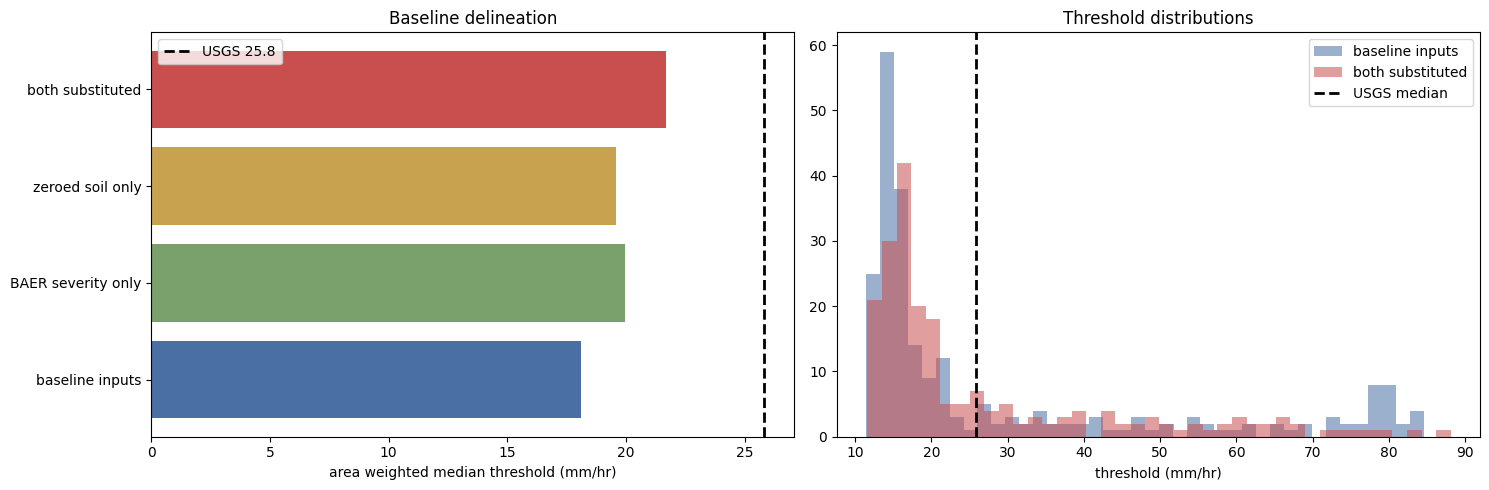

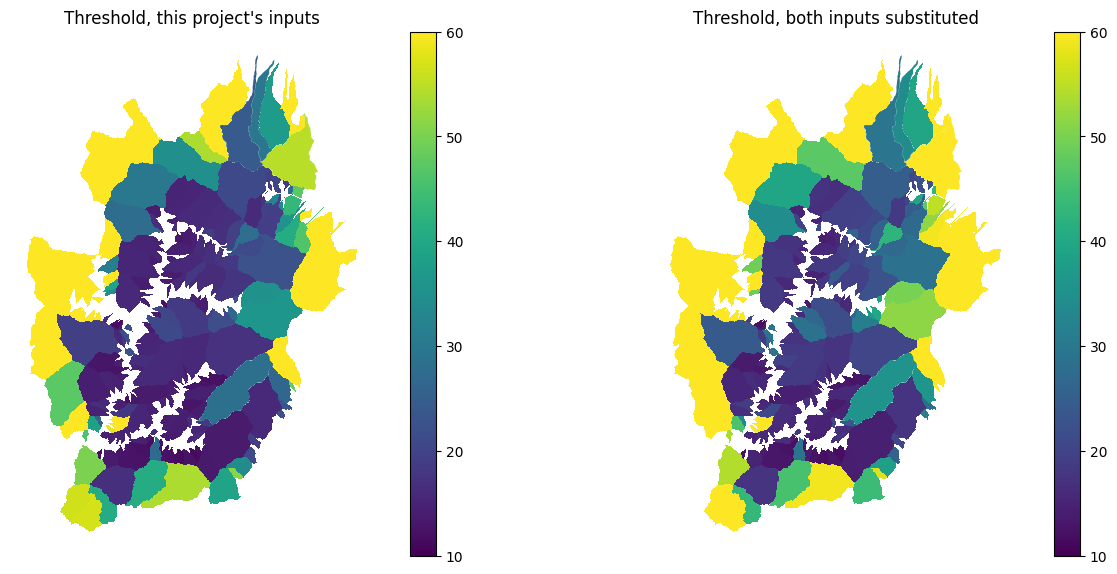

In [9]:
# Cell 7 --- BAER severity and the zeroed soil rule, together

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Rebuild S under the zeroed rule ------------------------------------------
# Same source rows as cell 2; only the null handling changes. weighted_mean drops
# nulls and renormalises, so zeroing is done by substituting 0.0 before the call.
grouped = soils.group_rows_by_component(rows)
by_mu = {}
for cokey, comp in grouped.items():
    by_mu.setdefault(str(comp['mukey']), []).append(
        (comp['comppct'], comp['horizons']))

def surface_kf(horizons):
    return horizons[0][1] if horizons else np.nan

kf_zeroed = {}
for mukey, comps in by_mu.items():
    pcts = [c[0] for c in comps]
    surf = [0.0 if (surface_kf(c[1]) != surface_kf(c[1])) else surface_kf(c[1])
            for c in comps]
    kf_zeroed[mukey], _ = soils.weighted_mean(surf, pcts)

print('--- KF per map unit ---')
for k in sorted(kf_zeroed):
    base = kf_lookup.get(k)
    print(f'  {k}: dropped {base[0]:.4f}  zeroed {kf_zeroed[k]:.4f}'
          if base else f'  {k}: zeroed {kf_zeroed[k]:.4f}')

# --- Four combinations, both delineations -------------------------------------
REFERENCE_STORM = 24
INTENSITY = m1.RainfallConvention.INTENSITY_MM_HR
USGS_REF = {'thr': 25.8, 'High_pct': 37.2, 'T_area': 0.376, 'S_area': 0.144}

def warea_median(v, weights):
    okm = np.isfinite(v) & (weights > 0)
    v, weights = np.asarray(v)[okm], np.asarray(weights)[okm]
    o = np.argsort(v); v, weights = v[o], weights[o]
    c = np.cumsum(weights) / weights.sum()
    return float(v[np.searchsorted(c, 0.5)])

rows_out, combined = [], {}
for run_name in ['baseline', 'ultrafine']:
    gdf = swapped[run_name].copy()

    # S under the zeroed rule, area weighted from the same STATSGO polygons.
    inter = gpd.overlay(gdf[['id', 'geometry']], mu[['mukey', 'geometry']],
                        how='intersection', keep_geom_type=True)
    inter['area_m2'] = inter.geometry.area
    s_rows = []
    for bid, grp in inter.groupby('id'):
        kfs = [kf_zeroed.get(str(k), np.nan) for k in grp.mukey]
        val, _ = soils.weighted_mean(kfs, grp.area_m2.tolist())
        s_rows.append({'id': bid, 'S_zeroed': float(val)})
    gdf = gdf.merge(pd.DataFrame(s_rows), on='id', how='left')

    COMBOS = {
        'baseline inputs':      ('T', 'S'),
        'BAER severity only':   ('T_baer', 'S'),
        'zeroed soil only':     ('T', 'S_zeroed'),
        'both substituted':     ('T_baer', 'S_zeroed'),
    }

    wt = gdf.burned_cells.to_numpy() * 100.0
    for label, (tcol, scol) in COMBOS.items():
        thr, p24 = [], []
        for _, r in gdf.iterrows():
            if not np.isfinite(r[tcol]) or not np.isfinite(r[scol]):
                thr.append(np.nan); p24.append(np.nan); continue
            bv = m1.BasinVariables(T=float(r[tcol]), F=float(r['F']),
                                   S=float(r[scol]))
            p24.append(float(m1.likelihood(bv, REFERENCE_STORM,
                                           convention=INTENSITY, duration_min=15)))
            try:
                thr.append(float(m1.accumulation(bv, target_p=0.5,
                                                 duration_min=15,
                                                 out_convention=INTENSITY)))
            except Exception:
                thr.append(np.inf)
        key = label.replace(' ', '_')
        gdf[f'thr_{key}'] = thr
        gdf[f'p24_{key}'] = p24

        p_arr = np.asarray(p24, dtype=float)
        rows_out.append({
            'delineation': run_name, 'run': label,
            'area_wt_T': warea_median(gdf[tcol].to_numpy(), wt),
            'area_wt_S': warea_median(gdf[scol].to_numpy(), wt),
            'area_wt_thr': warea_median(np.asarray(thr, dtype=float), wt),
            'area_High_pct': float(
                wt[np.isfinite(p_arr) & (p_arr >= 0.6)].sum() / wt.sum() * 100),
        })
    combined[run_name] = gdf
    gdf.to_file(SENS_DIR / f'basins_{run_name}_combined.geojson', driver='GeoJSON')

res = pd.DataFrame(rows_out)
print('\n=== Substituting USGS inputs ===')
print(res.round(3).to_string(index=False))
print(f'\nUSGS reference: T {USGS_REF["T_area"]:.3f}, S {USGS_REF["S_area"]:.3f}, '
      f'{USGS_REF["thr"]:.1f} mm/hr, {USGS_REF["High_pct"]:.1f}% of area High')

# --- How much of the gap does each close? -------------------------------------
print('\n--- Share of the threshold gap closed ---')
for run_name in ['baseline', 'ultrafine']:
    r = res[res.delineation == run_name].set_index('run')
    base = r.loc['baseline inputs', 'area_wt_thr']
    gap = USGS_REF['thr'] - base
    print(f'\n{run_name}: baseline {base:.2f} mm/hr, USGS {USGS_REF["thr"]:.2f}, '
          f'gap {gap:+.2f}')
    for label in ['BAER severity only', 'zeroed soil only', 'both substituted']:
        v = r.loc[label, 'area_wt_thr']
        print(f'  {label:20s} {v:6.2f} mm/hr   closes {(v - base) / gap * 100:5.0f}%'
              f'   residual {USGS_REF["thr"] - v:+.2f}')

# --- Plots --------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
r = res[res.delineation == 'baseline'].set_index('run')
labels = ['baseline inputs', 'BAER severity only', 'zeroed soil only',
          'both substituted']
vals = [r.loc[l, 'area_wt_thr'] for l in labels]
ax[0].barh(labels, vals, color=['#4a6fa5', '#7aa06b', '#c9a24f', '#c94f4f'])
ax[0].axvline(USGS_REF['thr'], color='k', ls='--', lw=2, label='USGS 25.8')
ax[0].set_xlabel('area weighted median threshold (mm/hr)')
ax[0].set_title('Baseline delineation'); ax[0].legend()

g = combined['baseline']
for l, c in [('baseline inputs', '#4a6fa5'), ('both substituted', '#c94f4f')]:
    v = pd.to_numeric(g[f'thr_{l.replace(" ", "_")}'], errors='coerce') \
          .replace([np.inf, -np.inf], np.nan).dropna()
    ax[1].hist(v[v < 90], bins=40, alpha=0.55, label=l, color=c)
ax[1].axvline(USGS_REF['thr'], color='k', ls='--', lw=2, label='USGS median')
ax[1].set_xlabel('threshold (mm/hr)'); ax[1].legend()
ax[1].set_title('Threshold distributions')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
g.plot(column='thr_baseline_inputs', ax=ax[0], cmap='viridis', vmin=10, vmax=60,
       legend=True)
ax[0].set_title('Threshold, this project\'s inputs'); ax[0].axis('off')
g.plot(column='thr_both_substituted', ax=ax[1], cmap='viridis', vmin=10, vmax=60,
       legend=True)
ax[1].set_title('Threshold, both inputs substituted'); ax[1].axis('off')
plt.tight_layout(); plt.show()

---
# Findings

## The question this notebook answers

Notebook `02b` compared this project's Bridge Fire assessment against the USGS
operational one. The two agree on burn severity measurement (r = 0.965) and on
where the hazard is: 99.8% of the ground USGS rates High is also rated High here.
They differ on magnitude, with this project consistently more hazardous by
roughly 7.7 mm/hr of area-weighted median rainfall threshold.

That difference was attributed roughly half to terrain and roughly a third to
soil, but the terrain share was confounded with basin size. USGS delineated 562
catchments at a median of 0.082 km²; this project 237 at 0.379 km². Small basins
sit on a single hillslope and take extreme values of T, larger ones average
across ridges and gullies, so the two effects could not be separated.

This notebook separates them, and then goes further by substituting the actual
USGS inputs.

## Study A: delineation scale explains none of it

The pipeline was run at four minimum basin areas, holding the maximum at 8 km² so
any result is attributable to one end of the range rather than both.

| Run | minimum area | basins | median basin | area-weighted T | threshold |
|---|---|---|---|---|---|
| ultrafine | 0.02 km² | 566 | 0.070 km² | 0.684 | 17.76 mm/hr |
| fine | 0.05 km² | 352 | 0.194 km² | 0.684 | 18.01 mm/hr |
| baseline | 0.10 km² | 237 | 0.379 km² | 0.670 | 18.11 mm/hr |
| coarse | 0.50 km² | 106 | 1.653 km² | 0.636 | 19.33 mm/hr |

**The ultrafine run matches the USGS delineation almost exactly**, and not by
chance. USGS documents that likelihood is estimated along drainage networks at
pixels where contributing area is at least 0.02 km², which is the value used
here. It produced 566 basins at a median of 0.070 km² against their 562 at
0.082 km².

At that scale, area-weighted T is 0.684, identical to three decimals to the run
at 0.05 km² and barely different from the baseline. Across an 8.5-fold change in
median basin size, T moves by 0.05. The threshold moves 0.35 mm/hr against a
7.7 mm/hr gap, and in the wrong direction: smaller basins give slightly *higher*
T here, while USGS has both smaller basins and lower T.

**Delineation scale accounts for none of the terrain difference.**

One methodological note. The plain median of T across these runs moves a great
deal (0.822 to 0.482) while the area-weighted median barely moves. A plain median
counts a 0.05 km² sliver the same as a 5 km² canyon, so it tracks how many small
basins exist rather than what the terrain is like. All figures here are area
weighted for that reason, and the USGS published median T of 0.531 is a plain
median over their catchments and is not directly comparable. The comparable USGS
figure, computed per unit area in `02b`, is 0.376.

## Study B: substituting the actual USGS inputs

### What their severity variable actually is

USGS documentation defines the terrain variable as the proportion of upslope area
in BARC class 3 or 4 with gradients at or above 23 degrees. BARC classes are not a
fixed dNBR threshold. BAER teams classify a dNBR raster into four classes using
break values chosen per fire, then adjust those breaks and hand-correct
individual areas from field observation, for example remapping pixels where soil
burn severity did not match the canopy condition above it.

For the Bridge Fire, BAER published the outcome: of 54,659 acres analysed, about
42% unburned to low, 51% moderate and 7% high. **Moderate or high is 58%.** This
project's dNBR >= 270 classification gives **76.5%**, an overstatement of 18.5
percentage points, exactly the direction predicted for chaparral where shrubs
burn to nothing above ground while the soil beneath is only moderately affected.

### Verifying the raster before using it

The BAER soil burn severity product is published as a national mosaic. The export
for this burn area returned 51.1% moderate and 6.9% high inside the perimeter,
against BAER's published 51% and 7%, at 97% coverage. Every class within 0.2
percentage points of a figure that came from a Forest Service release rather than
from anything in this pipeline. That confirms the correct fire and the correct
class encoding before anything was computed from it.

### Substituting severity alone

Only the moderate/high mask was changed. Same DEM, same Horn slope, same routing,
same basins, same soil, and F left as this project's dNBR because USGS defines F
as mean catchment dNBR as well.

| | area-weighted T | threshold | % of burn area High |
|---|---|---|---|
| dNBR >= 270 | 0.670 | 18.11 mm/hr | 63.4% |
| BAER SBS 3 and 4 | 0.471 | 19.95 mm/hr | 52.1% |
| USGS | 0.376 | 25.80 mm/hr | 37.2% |

T falls by 30%, which is the largest single change any input has made to it. The
threshold moves 1.84 mm/hr, closing 24% of the gap. The smaller effect on the
threshold is the logistic saturating: at high T the model is already near
certainty, so a large drop in T produces a smaller move in the rainfall required.

**The severity difference is slope-independent.** On slopes at or above 23
degrees, BAER moderate-high is 56.6% against this project's 76.5%. Below 23
degrees, 54.2% against 76.3%. BAER downgrades steep and flat ground alike, which
rules out the possibility that their field corrections apply preferentially to
slopes.

**The correction is largest in moderately burned basins.** Plotted per basin,
every point falls on or below the 1:1 line, but basins near T = 0.9 barely move
while those between 0.4 and 0.7 drop by up to 0.3. Where the fire burned
hardest, satellite dNBR and field-validated soil severity agree. Where it burned
patchily, dNBR overstates it substantially. That is the chaparral mechanism made
visible.

### Substituting both severity and soil

The soil difference identified in `02b` was null KF handling: treating rock
outcrop and water as zero rather than dropping and renormalising them moves S
from 0.259 to 0.183 area weighted, against the USGS 0.144.

| Run | T | S | threshold | gap closed | residual |
|---|---|---|---|---|---|
| this project's inputs | 0.670 | 0.254 | 18.11 mm/hr | - | +7.69 |
| BAER severity only | 0.471 | 0.254 | 19.95 mm/hr | 24% | +5.85 |
| zeroed soil only | 0.670 | 0.183 | 19.57 mm/hr | 19% | +6.23 |
| **both substituted** | **0.471** | **0.183** | **21.69 mm/hr** | **47%** | **+4.11** |

The two effects are close to additive: 24% plus 19% predicts 43%, observed 47%.

Both delineations give 21.686 mm/hr, identical to three decimals, so delineation
is not a factor in the substitution either. That is now the third independent
demonstration of the same point.

## What remains unexplained

**A residual of 4.11 mm/hr, about half the original gap, concentrated in T.**

Even using the USGS field-validated severity map, at the USGS delineation scale,
T is 0.471 against their 0.376, still 25% higher. Severity classification is a
real and large contributor but it is not the whole terrain story.

The remaining candidates, in order of plausibility:

1. **"Upslope area" may not mean "basin polygon".** USGS reports per stream
   segment, summarising the drainage network above it. That region need not be
   identical to a catchment polygon even when the areas are comparable. This is
   the leading hypothesis and it has not been tested.
2. **Slope computation.** Both use 3DEP 10 m, but conditioning, resampling or the
   slope algorithm could differ. Horn's method is used here because it matches
   GDAL and ArcGIS.
3. Perimeter clipping is unlikely to explain it, since ground outside the
   perimeter counts as unburned here and would push T down rather than up.

## Confidence, stated separately for each component

These are not equally established and should not be reported as though they were.

**Verified.** The BAER severity substitution. The raster is the actual published
input, matched against its own published class proportions to within 0.2
percentage points before use.

**Verified.** Delineation scale contributing nothing. Demonstrated across four
scales spanning a 25-fold range of minimum area, including a direct match to the
documented USGS parameter.

**Fitted, not verified.** The soil rule. It was selected in `02b` because it came
closest to the USGS values among six candidates. Reporting it as an explanation
carries that circularity, and it should be described as the closest of several
tested rules rather than as an identified mechanism.

**Unresolved.** The 4.11 mm/hr residual.